# Start

## Procedures

### Introduction to Seaborn

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
quakes = pd.read_csv('earthquakes-1.csv')

In [4]:
# Display the September 28, 2018 earthquake
quakes.assign(
    time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
    "parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)

,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


<Axes: xlabel='magType', ylabel='mag'>

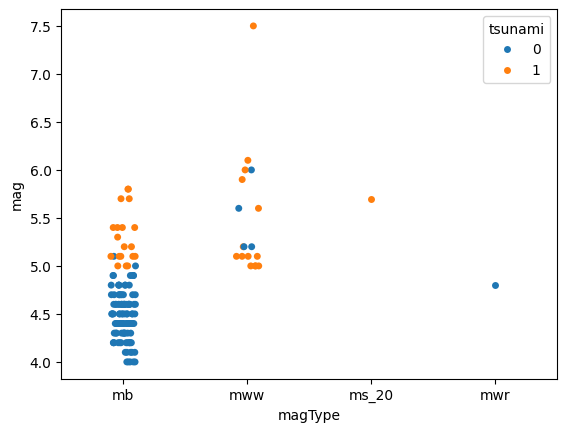

In [5]:
# stripplot()
sns.stripplot(
    x='magType', 
    y='mag', 
    hue='tsunami', 
    data=quakes.query('parsed_place == "Indonesia"')
)

<Axes: xlabel='magType', ylabel='mag'>

c:\Users\Neil Caccam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


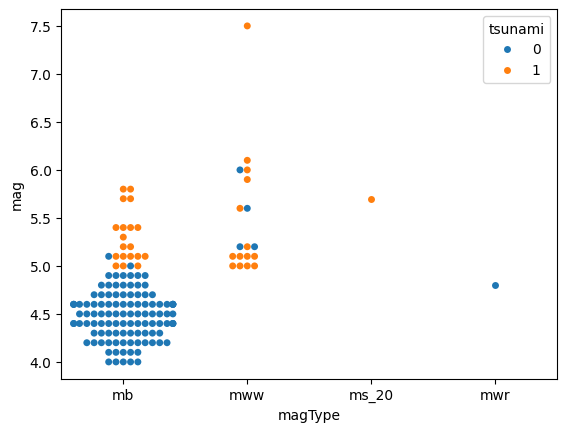

In [6]:
# swarmplot()
sns.swarmplot(
    x='magType', 
    y='mag', 
    hue='tsunami', 
    data=quakes.query('parsed_place == "Indonesia"')
)

<Axes: >

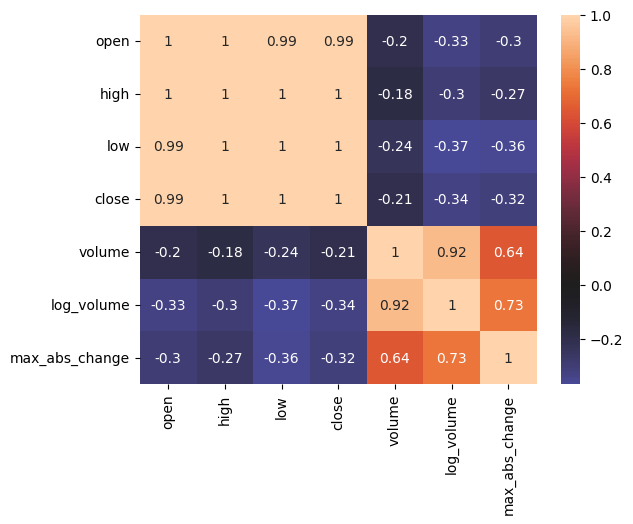

In [7]:
# heatmap()
sns.heatmap(
    fb.sort_index().assign(
        log_volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    ).corr(),
    annot=True, 
    center=0
)

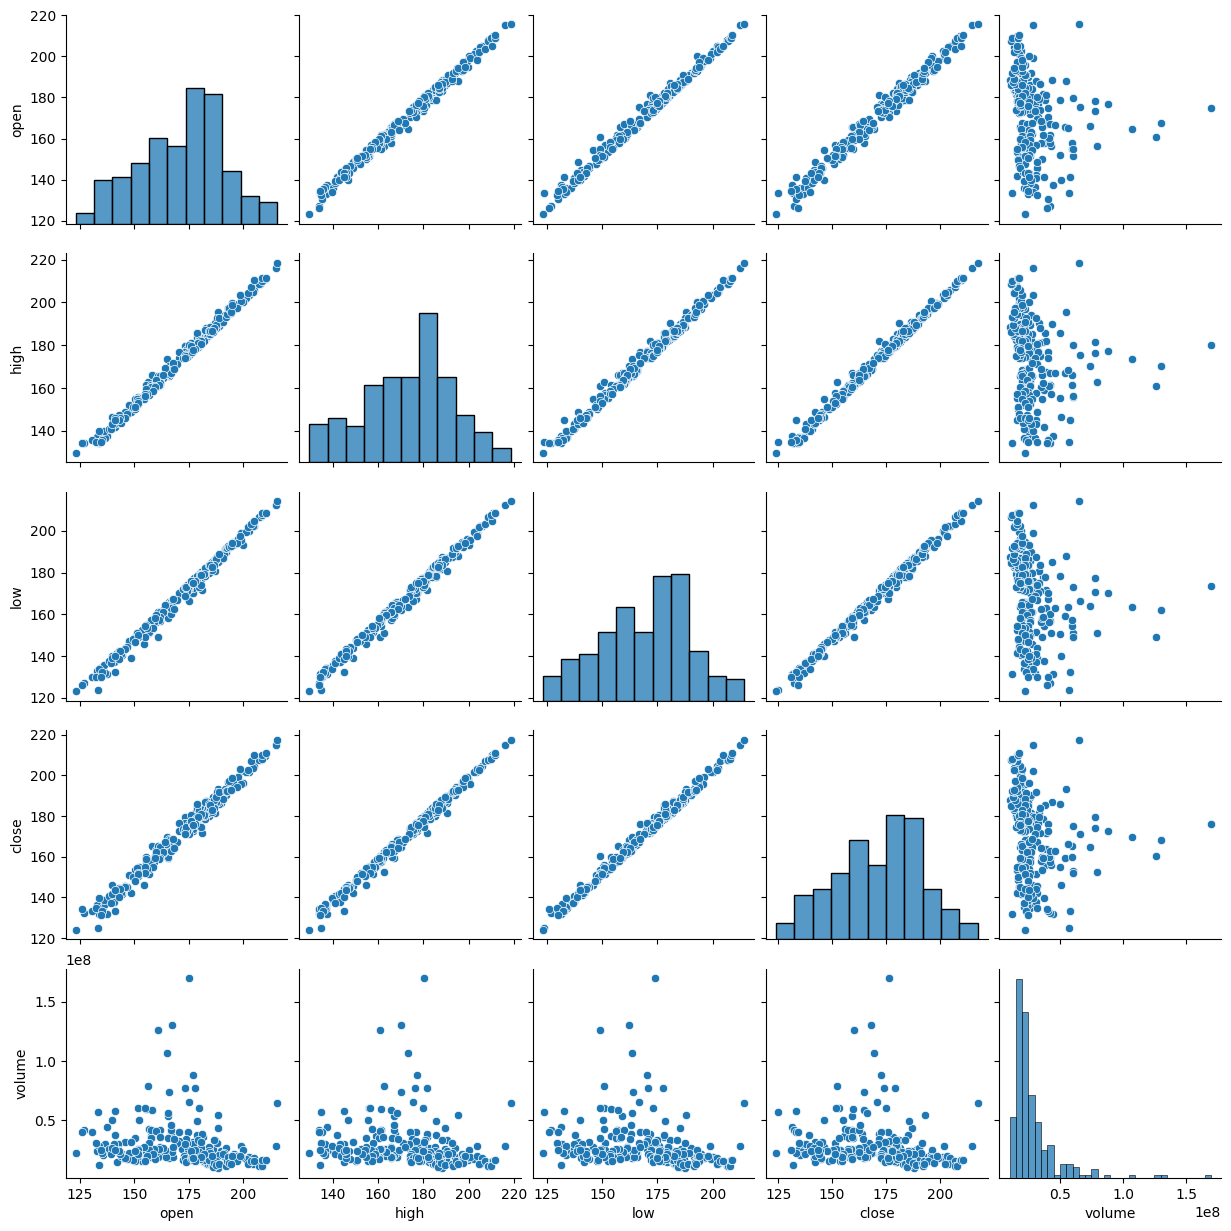

In [8]:
# pairplot()
sns.pairplot(fb)

In [9]:
# Prepare data for jointplots
fb_joint_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
)

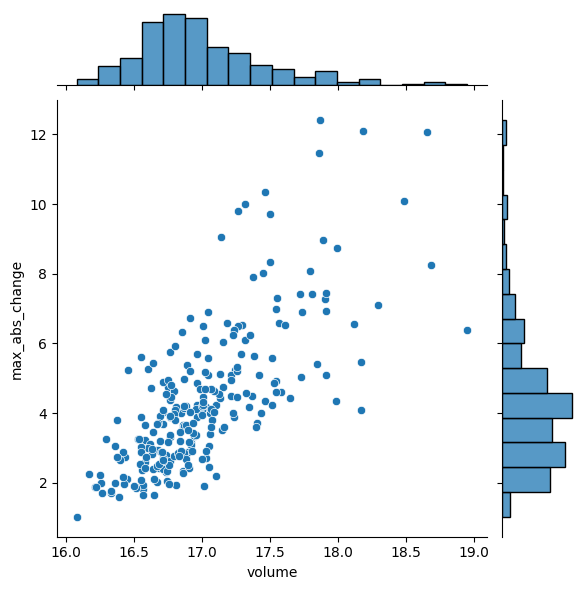

In [10]:
# jointplot() - default
sns.jointplot(
    x='volume',
    y='max_abs_change',
    data=fb_joint_data
)

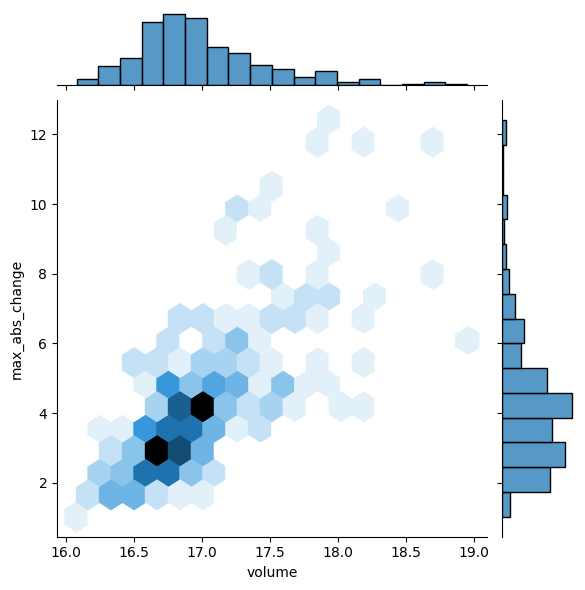

In [11]:
# jointplot() - hex
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='hex',
    data=fb_joint_data
)

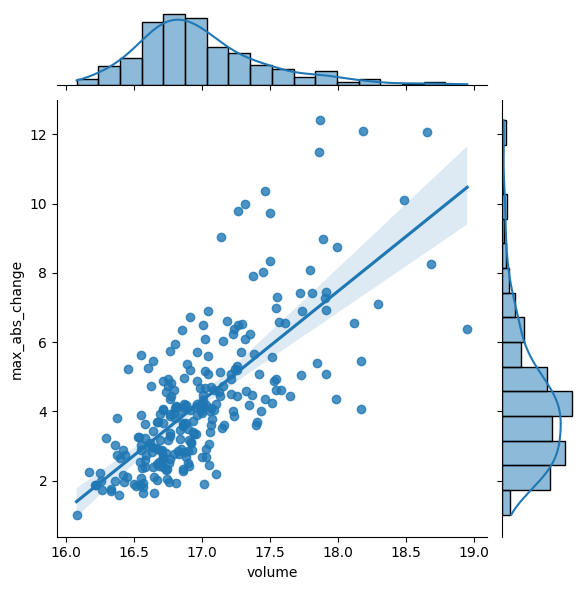

In [12]:
# jointplot() - reg
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='reg',
    data=fb_joint_data
)

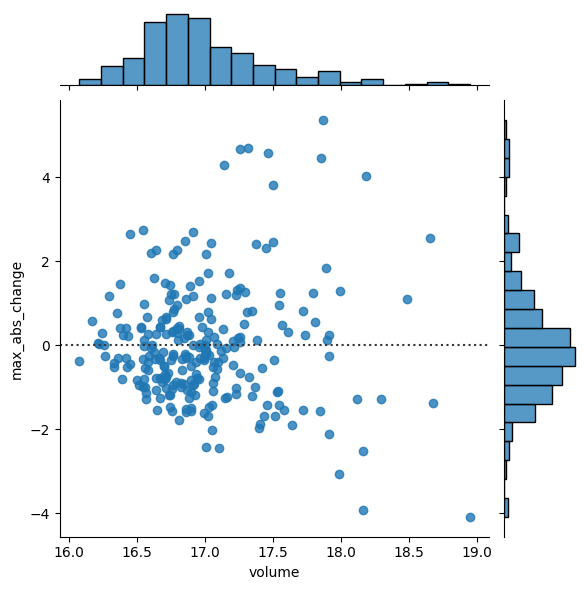

In [13]:
# jointplot() - resid
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='resid',
    data=fb_joint_data
)

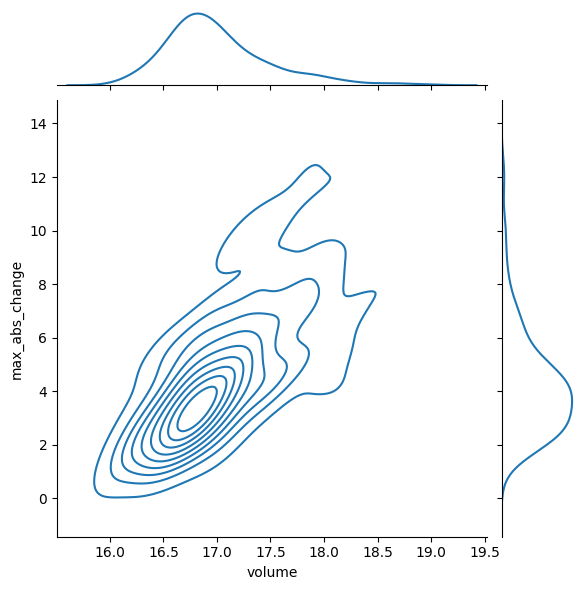

In [14]:
# jointplot() - kde
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='kde',
    data=fb_joint_data
)

In [15]:
# Regression data
fb_reg_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).iloc[:, -2:]

In [16]:
# Import itertools
import itertools

In [17]:
# Iterator example
iterator = itertools.repeat("I'm an iterator", 1)

for i in iterator:
    print(f'--->{i}')
print('This printed once because the iterator has been exhausted')
for i in iterator:
    print(f'--->{i}')

--->I'm an iterator
This printed once because the iterator has been exhausted


In [18]:
# Iterable example
iterable = list(itertools.repeat("I'm an iterable", 1))

for i in iterable:
    print(f'--->{i}')
print('This prints again because it\'s an iterable:')
for i in iterable:
    print(f'--->{i}')

--->I'm an iterable
This prints again because it's an iterable:
--->I'm an iterable


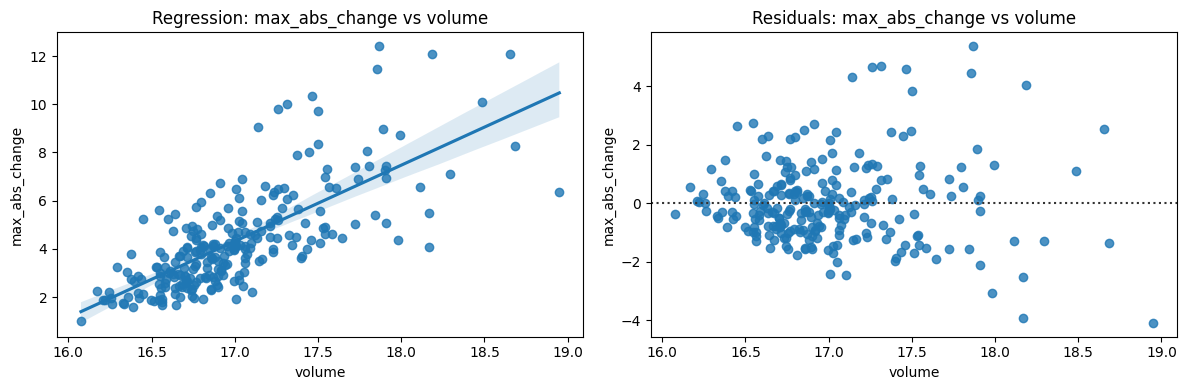

In [20]:
# reg_resid_plots
from reg_resid_plot import reg_resid_plots
reg_resid_plots(fb_reg_data)

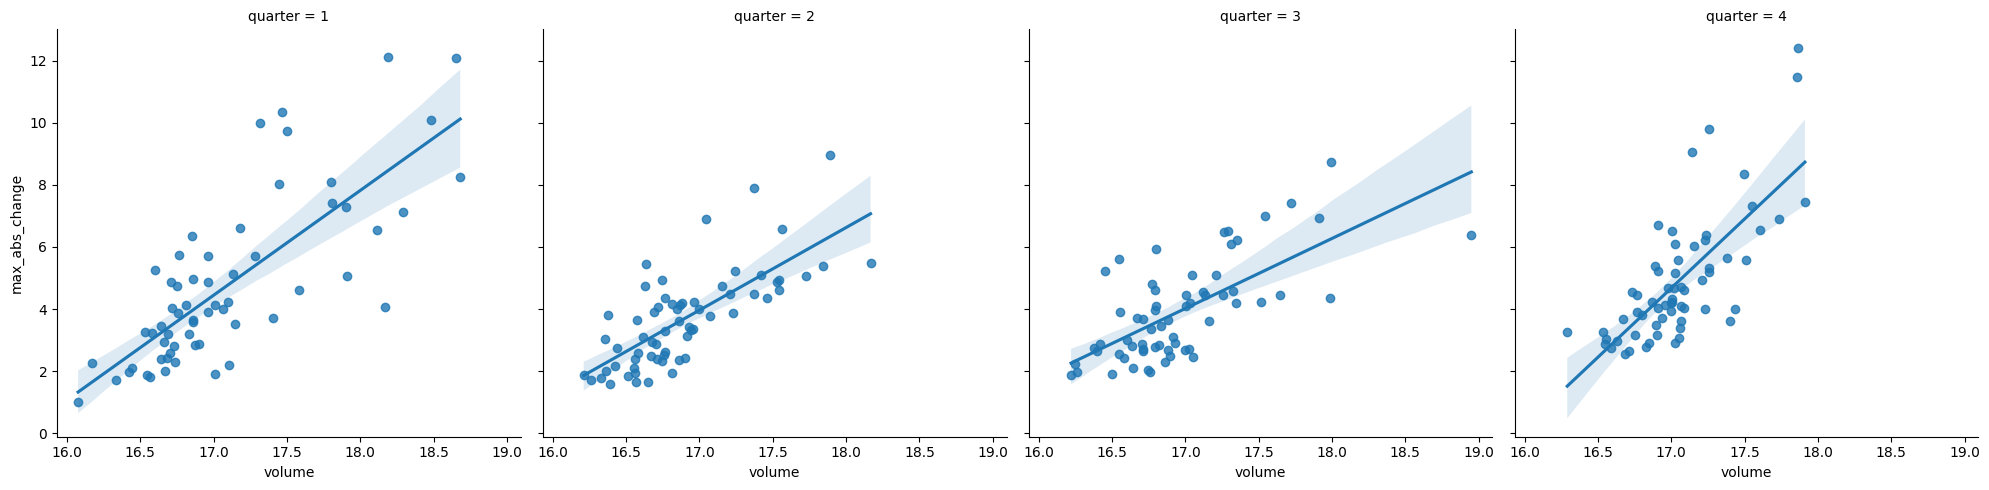

In [21]:
# lmplot()
sns.lmplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low,
        quarter=lambda x: x.index.quarter
    ),
    col='quarter'
)

Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

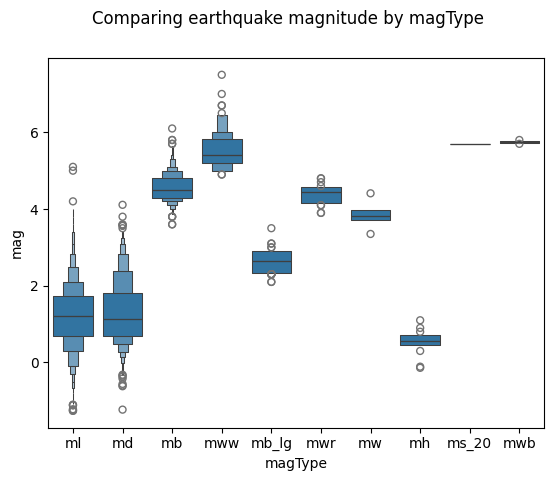

In [22]:
# boxenplot()
sns.boxenplot(
    x='magType', 
    y='mag', 
    data=quakes[['magType', 'mag']]
)
plt.suptitle('Comparing earthquake magnitude by magType')

C:\Users\Neil Caccam\AppData\Local\Temp\ipykernel_25744\298510179.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

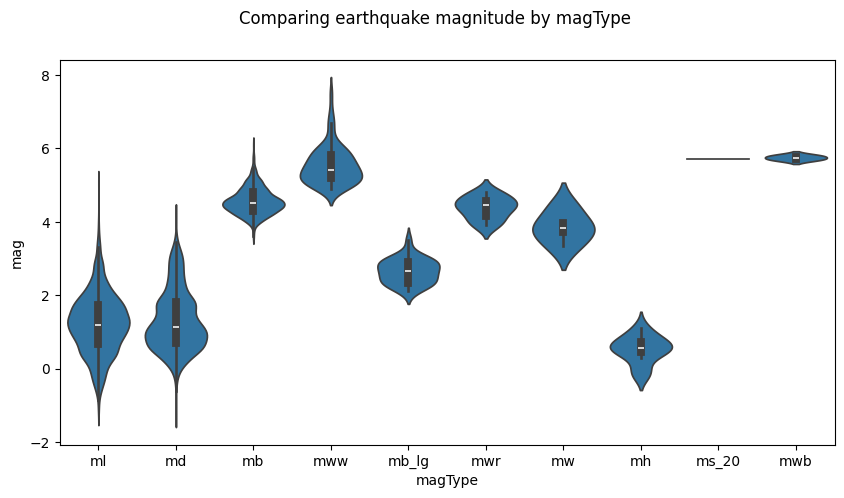

In [23]:
# violinplot()
fig, axes = plt.subplots(figsize=(10, 5))

sns.violinplot(
    x='magType', 
    y='mag', 
    data=quakes[['magType', 'mag']],
    ax=axes,
    scale='width'
)
plt.suptitle('Comparing earthquake magnitude by magType')

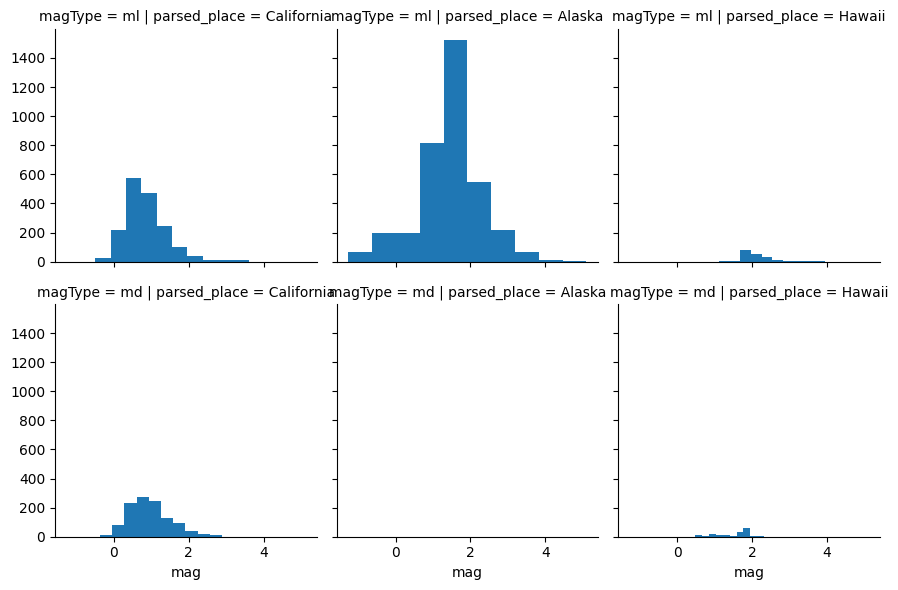

In [24]:
# Faceting
g = sns.FacetGrid(
    quakes[
        (quakes.parsed_place.isin(['California', 'Alaska', 'Hawaii'])) &
        (quakes.magType.isin(['ml', 'md']))
    ],
    row='magType',
    col='parsed_place'
)
g = g.map(plt.hist, 'mag')

#### Comment

Seaborn provides powerful visualization tools that make it easy to explore complex datasets, from categorical plots like stripplot and swarmplot for earthquake data to correlation heatmaps and jointplots for stock market analysis. The library's advanced features like faceting, regression plotting, and distribution visualizations (boxenplot, violinplot) reveal patterns and relationships that would be difficult to spot with basic plotting methods. Overall, Seaborn simplifies the creation of statistically informative graphics with minimal code, making it an essential tool for data analysis and visualization in Python.

### Formatting Plots

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import calendar
import matplotlib.ticker as ticker

fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

Text(0, 0.5, 'price ($)')

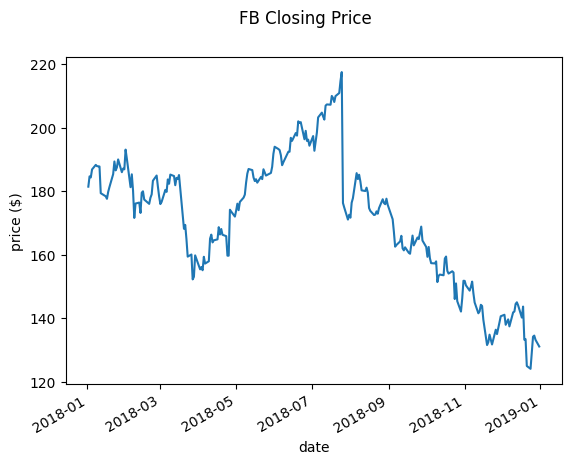

In [26]:
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')

Text(0, 0.5, 'price ($)')

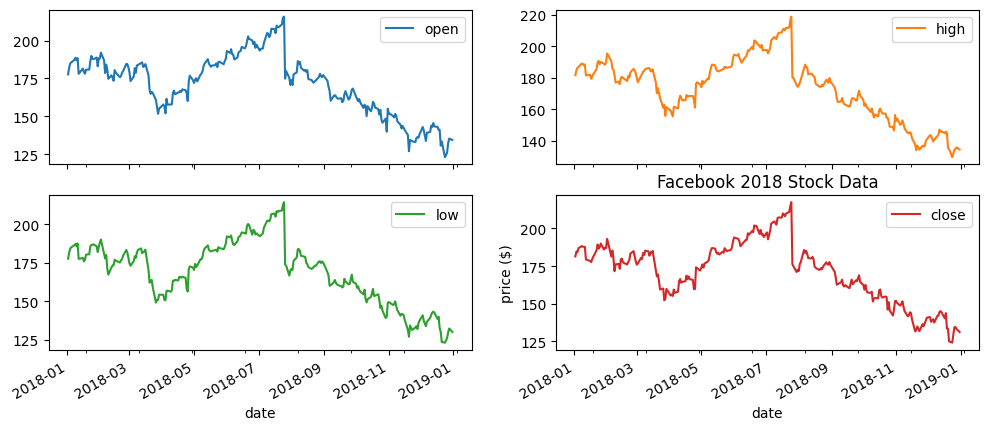

In [27]:
fb.iloc[:, :4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.title('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Text(0, 0.5, 'price ($)')

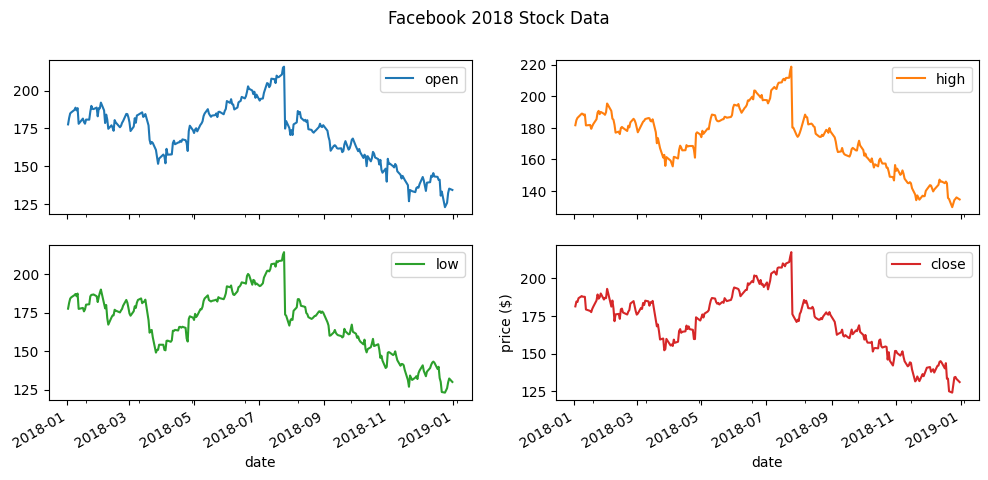

In [28]:
fb.iloc[:, :4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.suptitle('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Text(0, 0.5, 'price ($)')

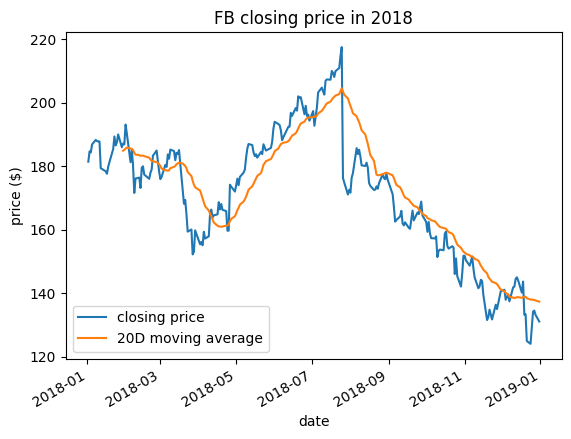

In [29]:
fb.assign(
    ma=lambda x: x.close.rolling(20).mean()
).plot(
    y=['close', 'ma'],
    title='FB closing price in 2018',
    label=['closing price', '20D moving average']
)
plt.legend(loc='lower left')
plt.ylabel('price ($)')

Text(0, 0.5, 'price ($)')

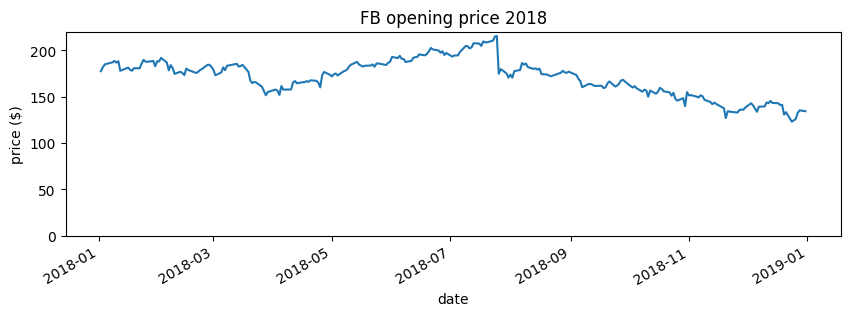

In [30]:
fb.open.plot(figsize=(10, 3), title='FB opening price 2018')
plt.ylim(0, None)
plt.ylabel('price ($)')


Text(0, 0.5, 'price ($)')

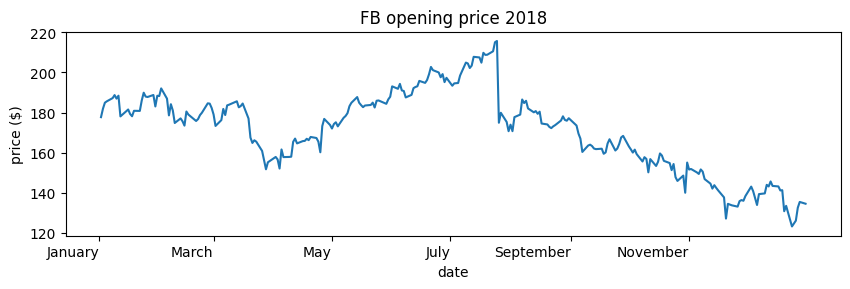

In [32]:
import calendar

fb.open.plot(figsize=(10, 3), rot=0, title='FB opening price 2018')
locs, labels = plt.xticks()
# Use only the first 6 tick locations to match 6 month labels
plt.xticks(locs[:6], calendar.month_name[1::2])
plt.ylabel('price ($)')


Text(0, 0.5, 'percent of highest price ($218.62)')

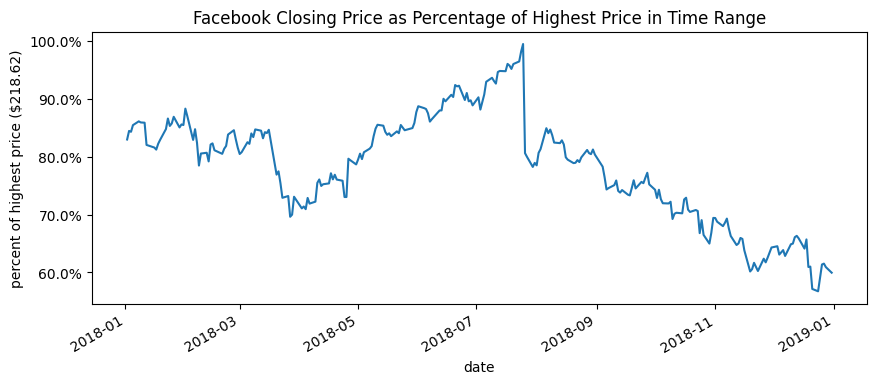

In [33]:
import matplotlib.ticker as ticker

ax = fb.close.plot(
    figsize=(10, 4),
    title='Facebook Closing Price as Percentage of Highest Price in Time Range'
)
ax.yaxis.set_major_formatter(
    ticker.PercentFormatter(xmax=fb.high.max())
)
ax.set_yticks([
    fb.high.max() * pct for pct in np.linspace(0.6, 1, num=5)
])  # show round percentages only (60%, 80%, etc.)
ax.set_ylabel(f'percent of highest price (${fb.high.max()})')

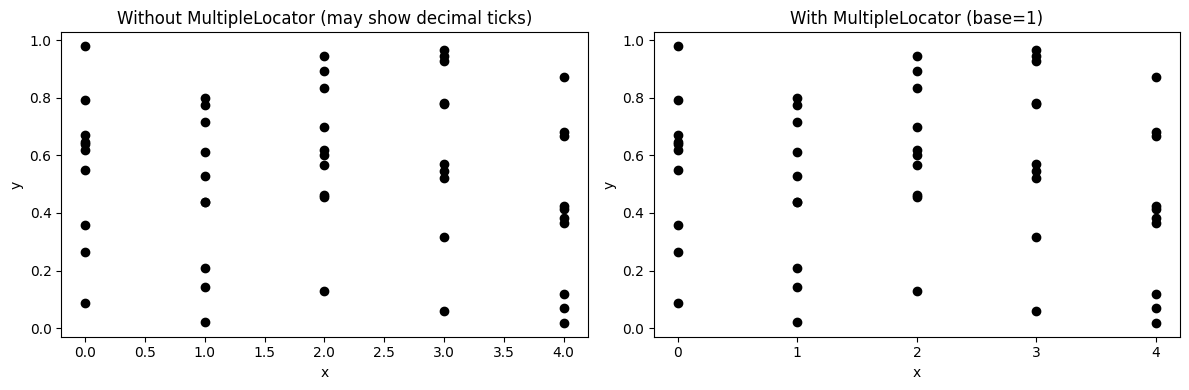

In [36]:
# Create sample data with integer x values
np.random.seed(0)
x = np.tile(np.arange(0, 5), 10)
y = np.random.rand(50)

# Plot without MultipleLocator (may show decimal ticks)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Without MultipleLocator
ax[0].plot(x, y, 'ko')
ax[0].set_title('Without MultipleLocator (may show decimal ticks)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

# With MultipleLocator
ax[1].plot(x, y, 'ko')
ax[1].get_xaxis().set_major_locator(ticker.MultipleLocator(base=1))
ax[1].set_title('With MultipleLocator (base=1)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')

plt.tight_layout()
plt.show()

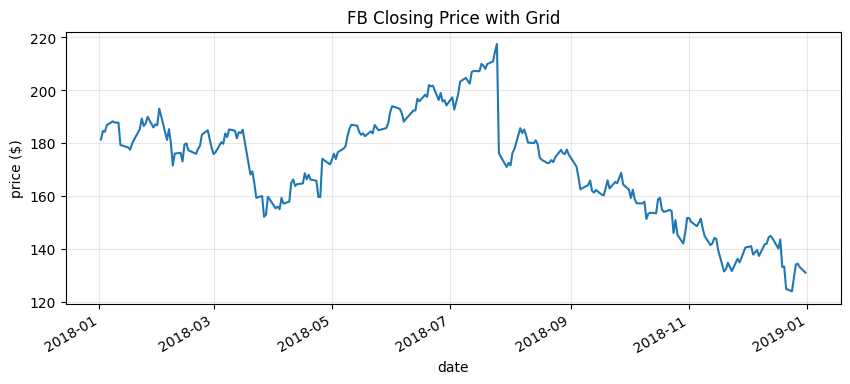

In [37]:
fb.close.plot(figsize=(10, 4), title='FB Closing Price with Grid')
plt.grid(True, alpha=0.3)
plt.ylabel('price ($)')
plt.show()

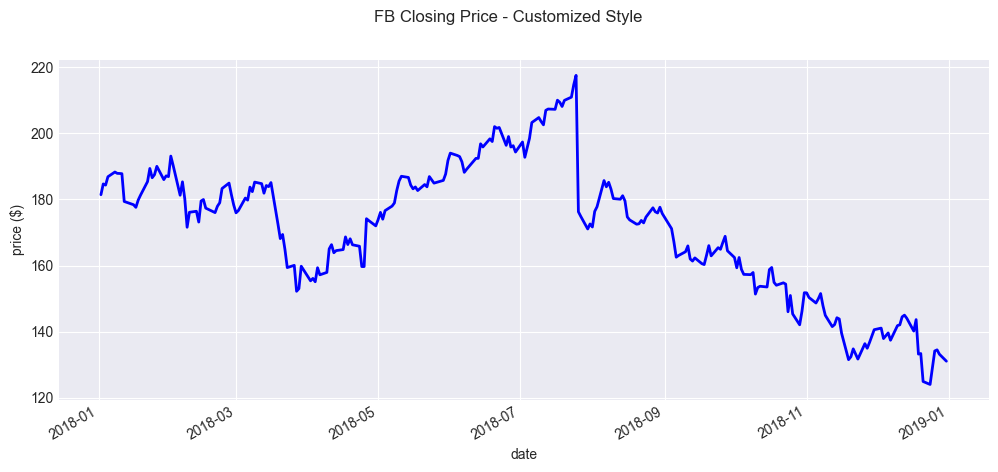

In [38]:
plt.style.use('seaborn-v0_8-darkgrid')
fb.close.plot(figsize=(12, 5), linewidth=2, color='blue')
plt.suptitle('FB Closing Price - Customized Style')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.show()

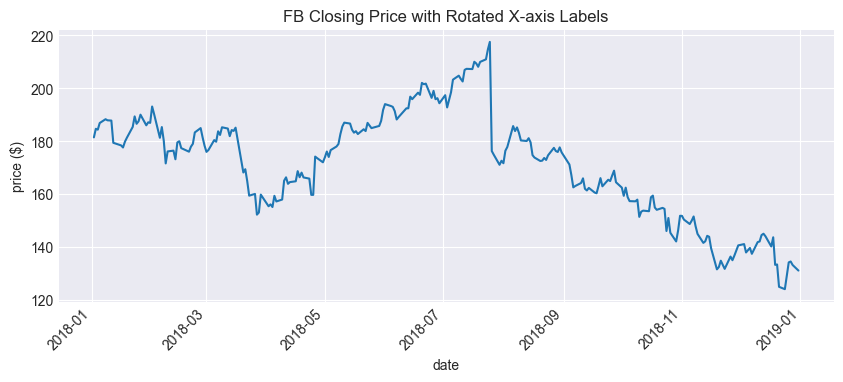

In [39]:
fb.close.plot(figsize=(10, 4))
plt.xticks(rotation=45)
plt.title('FB Closing Price with Rotated X-axis Labels')
plt.ylabel('price ($)')
plt.show()

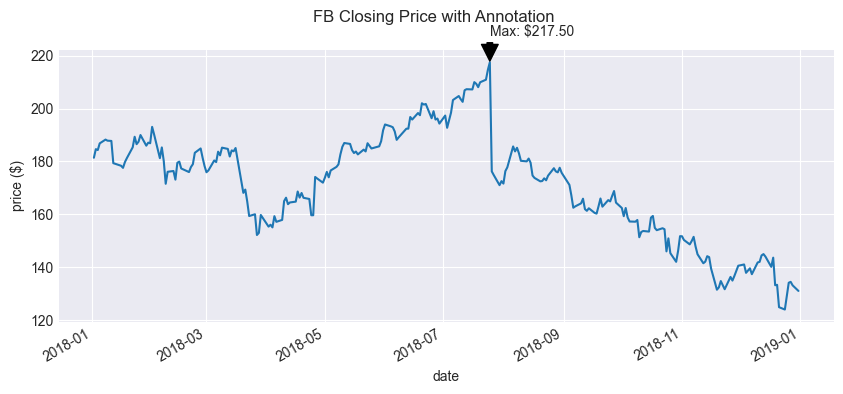

In [40]:
ax = fb.close.plot(figsize=(10, 4))
plt.suptitle('FB Closing Price with Annotation')
plt.xlabel('date')
plt.ylabel('price ($)')

# Add annotation at the maximum point
max_date = fb.close.idxmax()
max_price = fb.close.max()
plt.annotate(f'Max: ${max_price:.2f}', 
             xy=(max_date, max_price),
             xytext=(max_date, max_price + 10),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

#### Comment

This demonstrates essential formatting techniques in matplotlib that transform basic plots into publication quality visualizations. Key formatting skills covered include adding proper titles and axis labels, positioning legends, setting axis limits, customizing tick marks with calendar months and ticker formatters, and using MultipleLocator for cleaner axes. These formatting techniques are crucial for creating professional, readable plots that effectively communicate insights from data.


### Customizing Visualizations

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

# Display first few rows to verify data
fb.head()

,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


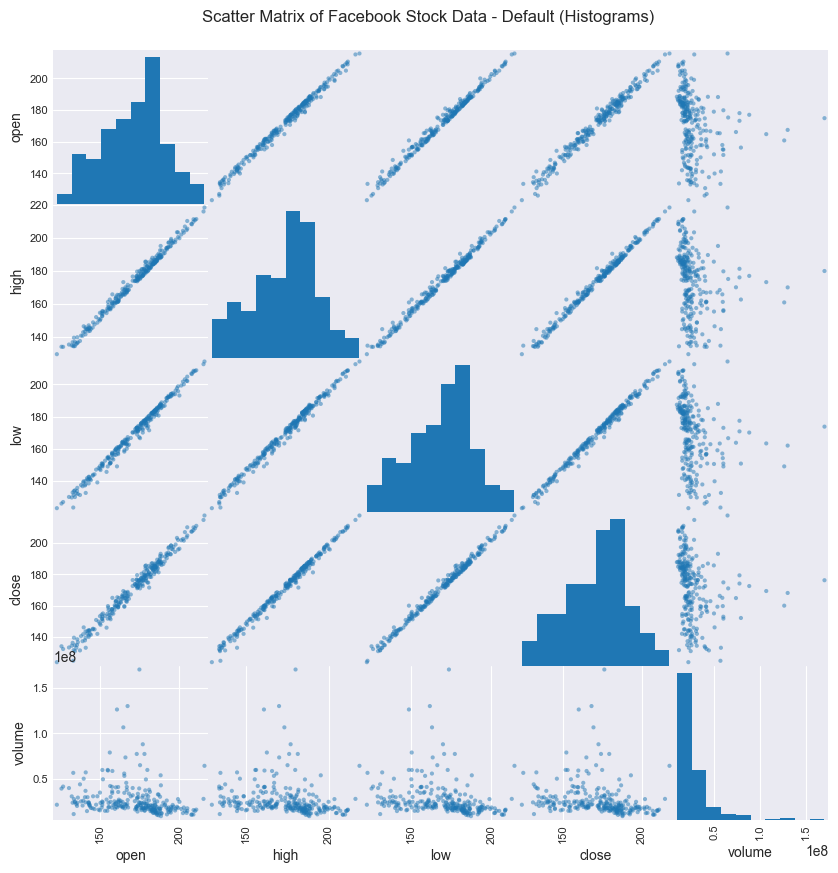

In [42]:
from pandas.plotting import scatter_matrix

scatter_matrix(fb, figsize=(10, 10))
plt.suptitle('Scatter Matrix of Facebook Stock Data - Default (Histograms)', y=0.92)
plt.show()


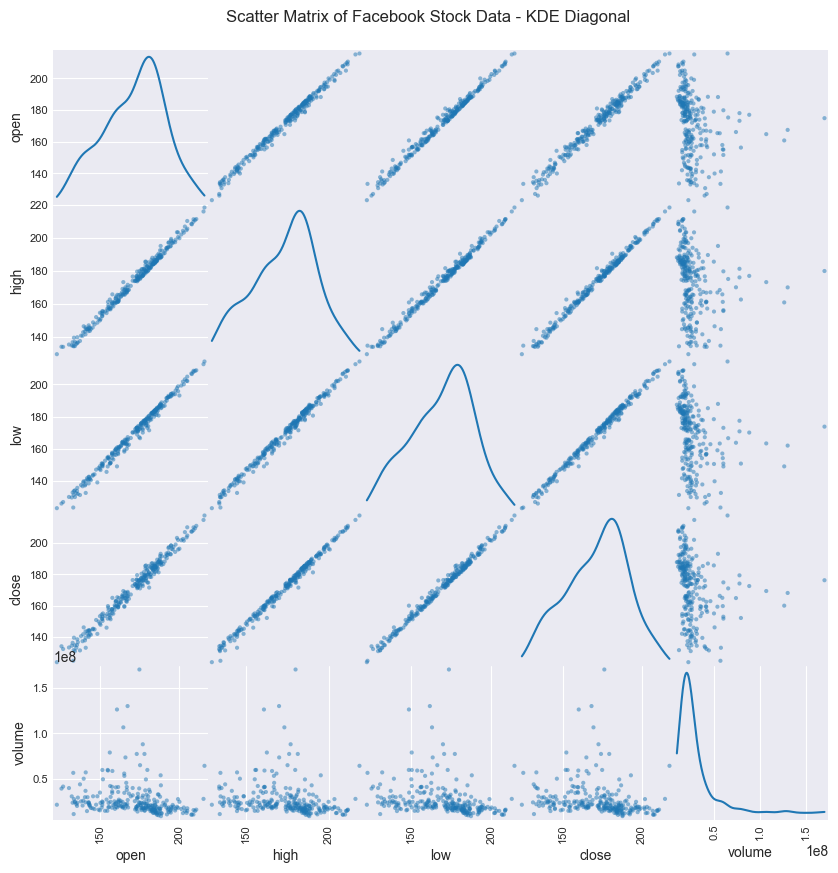

In [43]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')
plt.suptitle('Scatter Matrix of Facebook Stock Data - KDE Diagonal', y=0.92)
plt.show()

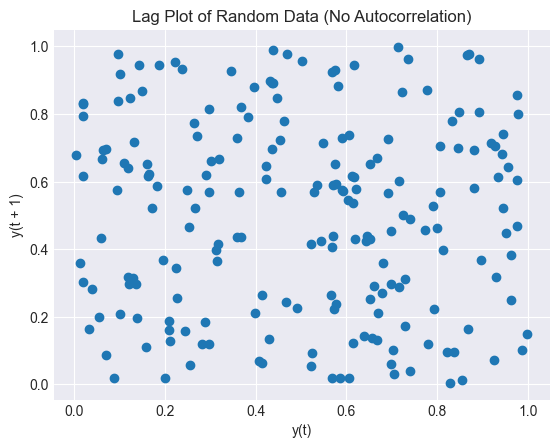

In [44]:
from pandas.plotting import lag_plot

np.random.seed(0)  # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))
plt.title('Lag Plot of Random Data (No Autocorrelation)')
plt.show()

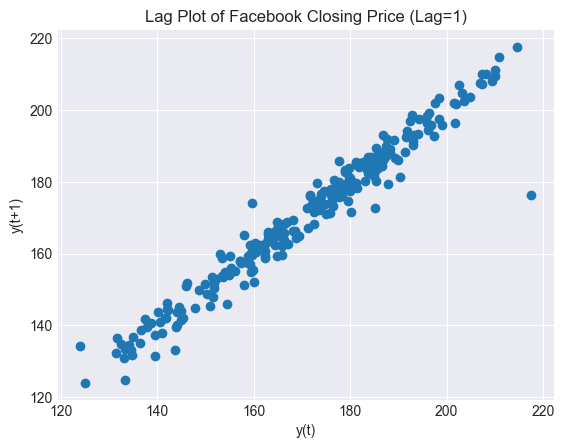

In [45]:
lag_plot(fb.close)
plt.title('Lag Plot of Facebook Closing Price (Lag=1)')
plt.xlabel('y(t)')
plt.ylabel('y(t+1)')
plt.show()

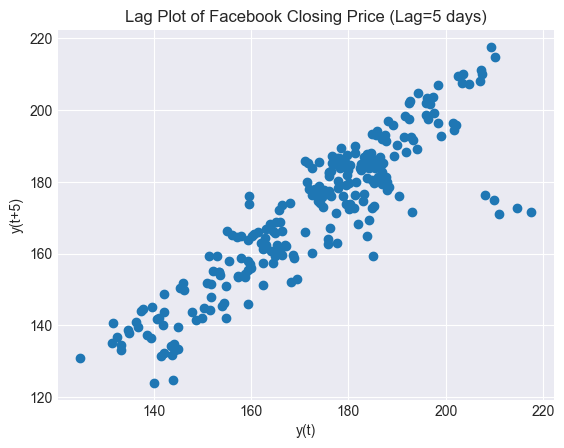

In [46]:
lag_plot(fb.close, lag=5)
plt.title('Lag Plot of Facebook Closing Price (Lag=5 days)')
plt.xlabel('y(t)')
plt.ylabel('y(t+5)')
plt.show()

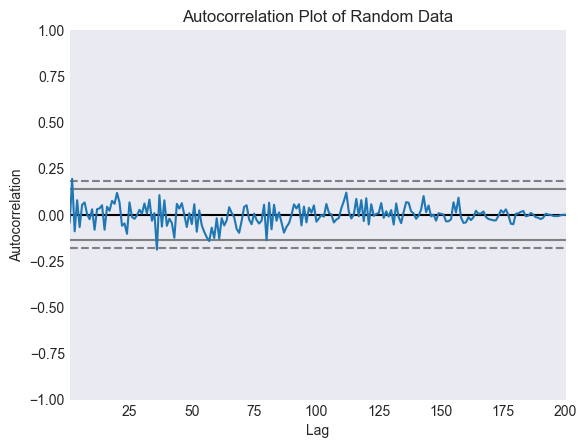

In [47]:
from pandas.plotting import autocorrelation_plot

np.random.seed(0)  # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))
plt.title('Autocorrelation Plot of Random Data')
plt.show()

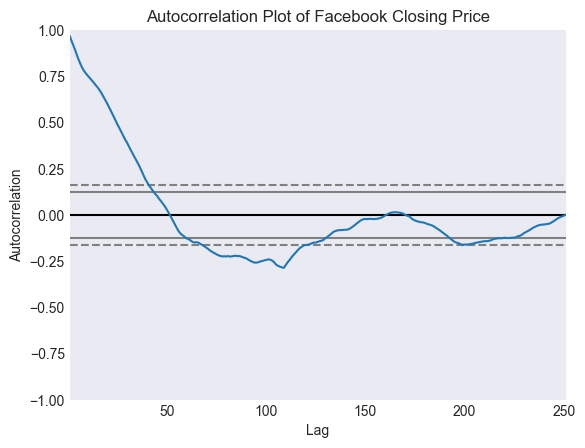

In [48]:
autocorrelation_plot(fb.close)
plt.title('Autocorrelation Plot of Facebook Closing Price')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

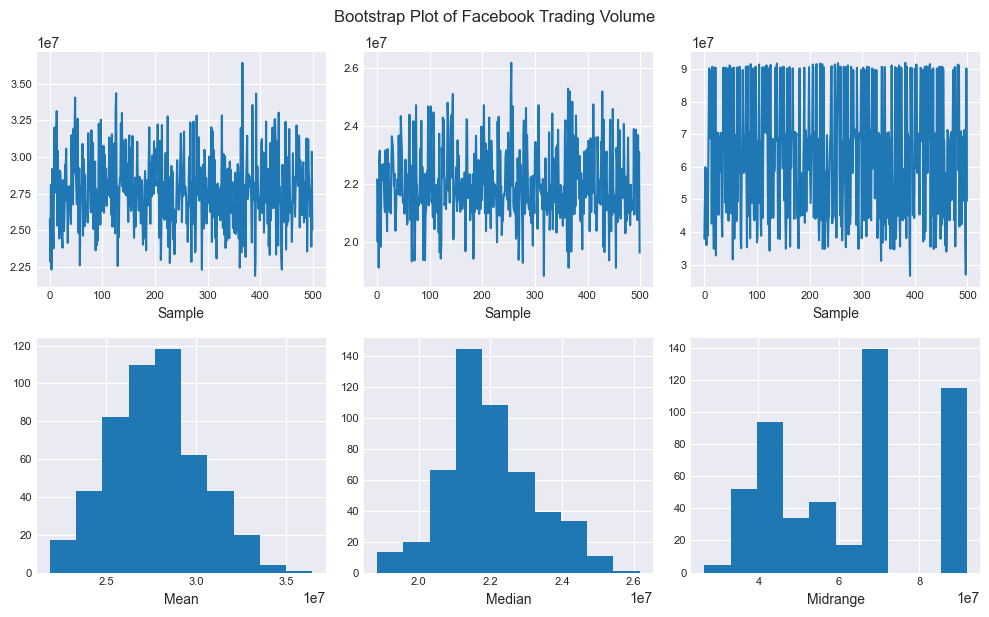

In [49]:
from pandas.plotting import bootstrap_plot

fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))
plt.suptitle('Bootstrap Plot of Facebook Trading Volume', y=1.02)
plt.show()

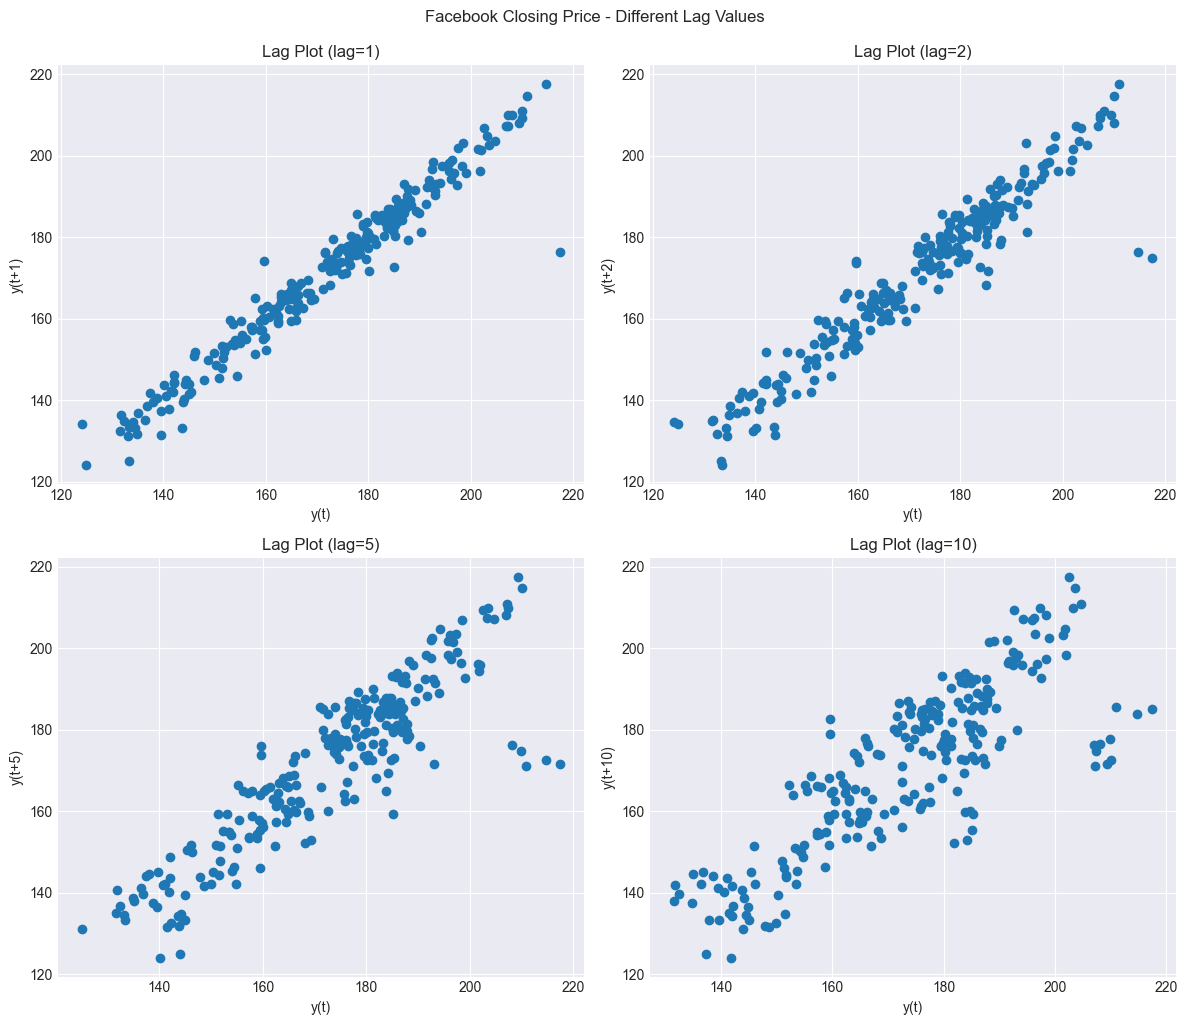

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
lags = [1, 2, 5, 10]

for i, lag in enumerate(lags):
    row, col = i // 2, i % 2
    lag_plot(fb.close, lag=lag, ax=axes[row, col])
    axes[row, col].set_title(f'Lag Plot (lag={lag})')
    axes[row, col].set_xlabel(f'y(t)')
    axes[row, col].set_ylabel(f'y(t+{lag})')

plt.tight_layout()
plt.suptitle('Facebook Closing Price - Different Lag Values', y=1.02)
plt.show()

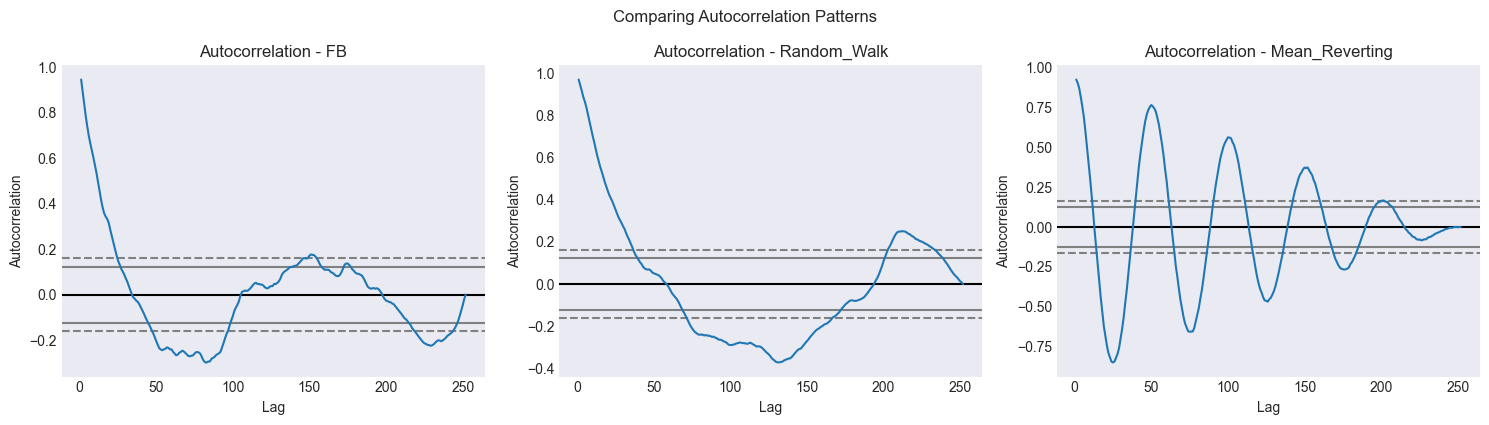

In [51]:
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', periods=252, freq='B')  # Business days
random_walk = np.cumsum(np.random.randn(252)) + 100
mean_reverting = 100 + 10 * np.sin(np.linspace(0, 10*np.pi, 252)) + np.random.randn(252) * 2

df_comparison = pd.DataFrame({
    'FB': fb.close.values[:252] if len(fb) >= 252 else np.cumsum(np.random.randn(252)) + 150,
    'Random_Walk': random_walk,
    'Mean_Reverting': mean_reverting
}, index=dates[:252])

# Plot autocorrelation for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(df_comparison.columns):
    autocorrelation_plot(df_comparison[col], ax=axes[i])
    axes[i].set_title(f'Autocorrelation - {col}')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.suptitle('Comparing Autocorrelation Patterns', y=1.05)
plt.show()

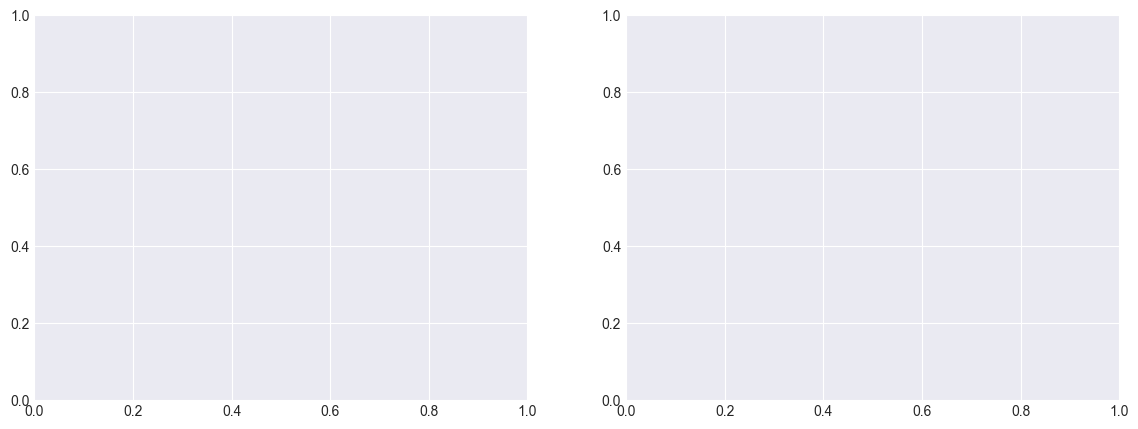

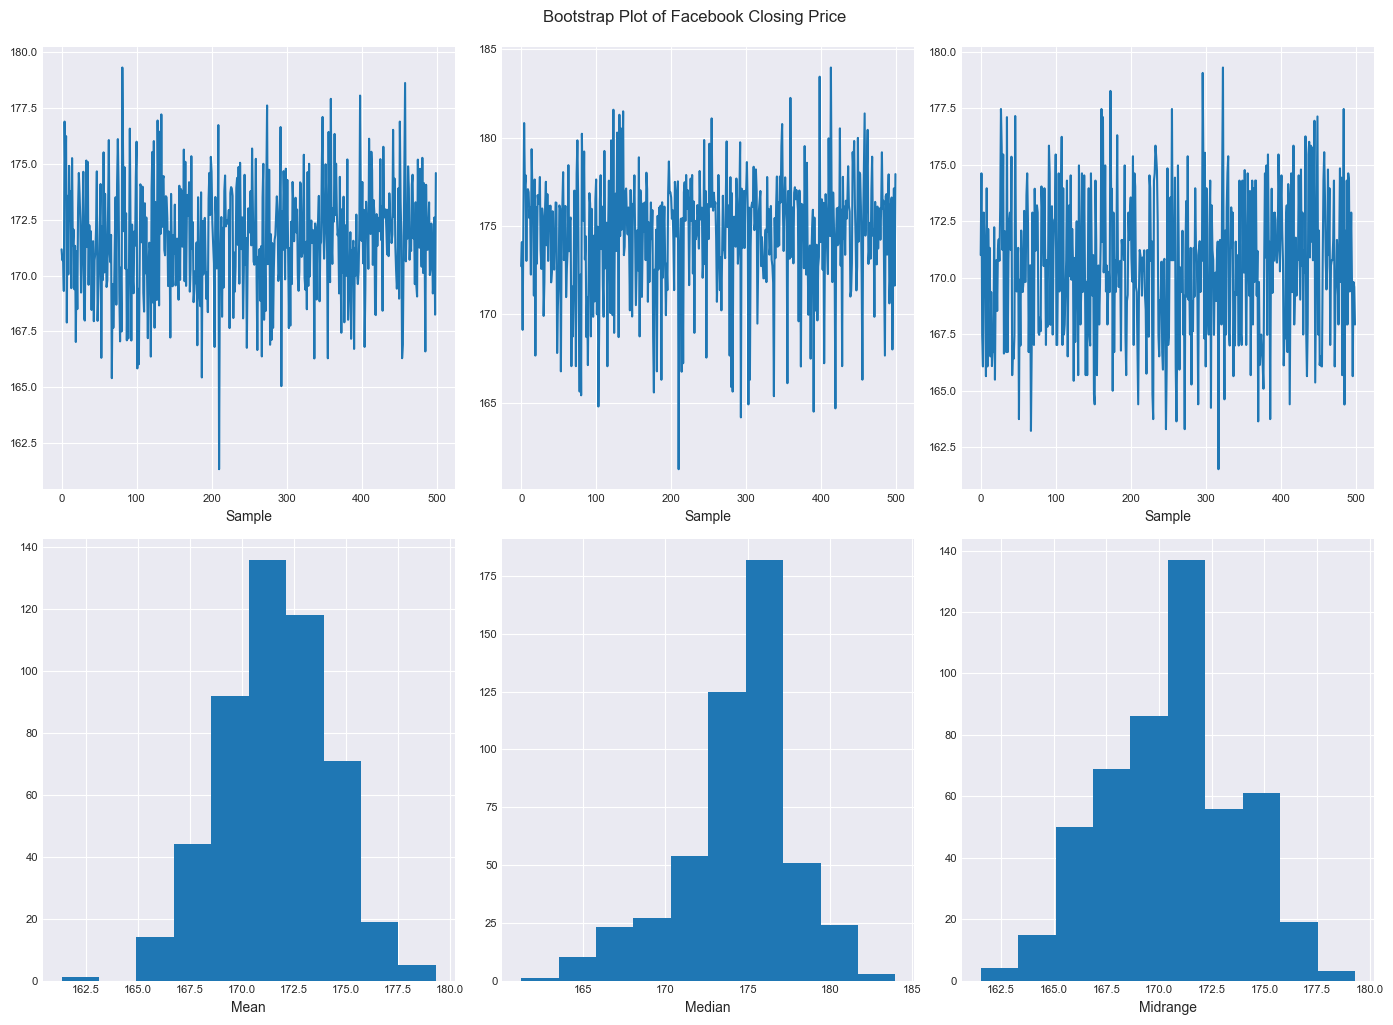

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bootstrap for mean
bootstrap_plot(fb.close, size=50, samples=500, fig=plt.figure(figsize=(14, 10)))
plt.suptitle('Bootstrap Plot of Facebook Closing Price', y=1.02)
plt.show()

#### Comment

The pandas.plotting subpackage provides specialized visualization tools for financial and time series analysis, including scatter matrices for exploring multivariate relationships, lag plots and autocorrelation plots for detecting autocorrelation patterns in temporal data, and bootstrap plots for understanding uncertainty in summary statistics. These built-in plotting functions extend pandas' core visualization capabilities, making it easier to perform exploratory data analysis on financial datasets like stock prices. Together, these tools help analysts quickly identify patterns, correlations, and statistical properties that might otherwise require more complex coding to uncover.

## Supplementary Activity

In [2]:
# Setup

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker
import itertools

# Load the data
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
quakes = pd.read_csv('earthquakes-1.csv')

print("Data loaded successfully!")
print(f"Facebook stock data shape: {fb.shape}")
print(f"Earthquakes data shape: {quakes.shape}")

Data loaded successfully!
Facebook stock data shape: (251, 5)
Earthquakes data shape: (9332, 6)


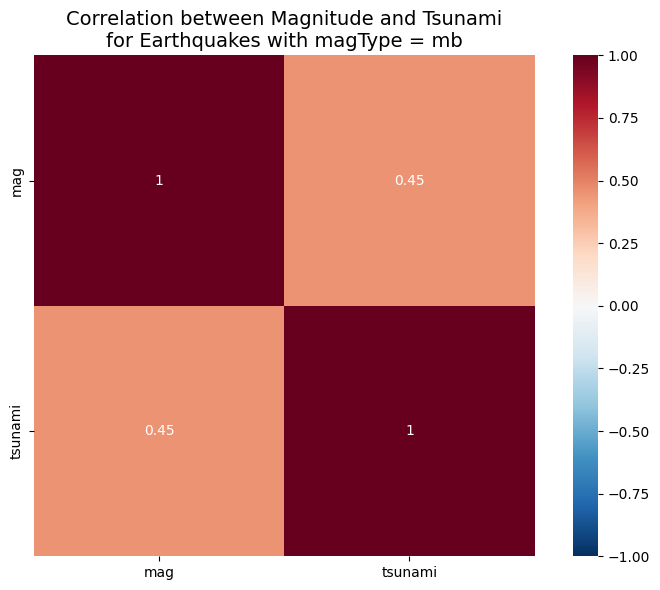

Correlation between magnitude and tsunami for mb magType: 0.4489


In [ ]:
# Exercise 1: Heatmap of earthquake correlations

# Filter data for mb magType
mb_quakes = quakes[quakes['magType'] == 'mb'].copy()

# Select only numeric columns for correlation
mb_corr_data = mb_quakes[['mag', 'tsunami']].dropna()

# Calculate correlation
mb_corr = mb_corr_data.corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    mb_corr, 
    annot=True, 
    center=0, 
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation between Magnitude and Tsunami\nfor Earthquakes with magType = mb', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Correlation between magnitude and tsunami for mb magType: {mb_corr.loc['mag', 'tsunami']:.4f}")

Volume bounds: Lower = -899775.00, Upper = 49042009.00
Close price bounds: Lower = 116.88, Upper = 226.30


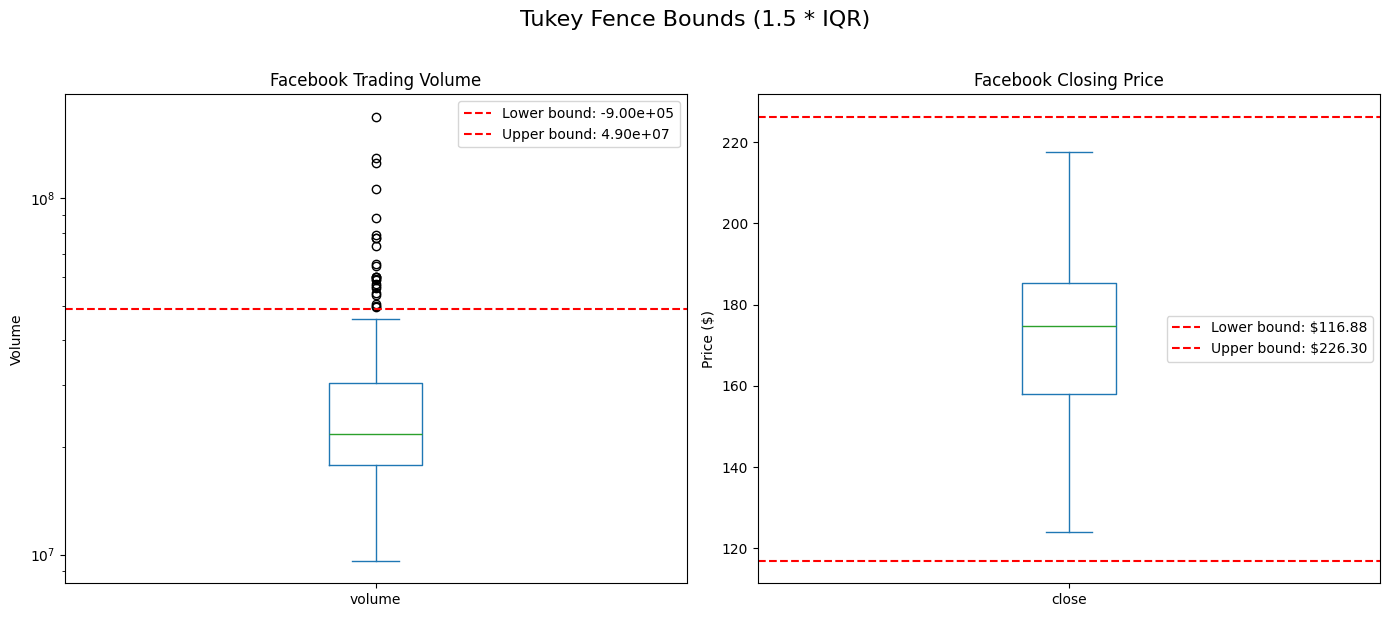

In [4]:
# Exercise 2: Box plot with Tukey fence bounds

# Calculate Tukey fence bounds for volume and close
def calculate_tukey_bounds(data, multiplier=1.5):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    return lower_bound, upper_bound

# Calculate bounds for volume and close
volume_lower, volume_upper = calculate_tukey_bounds(fb['volume'])
close_lower, close_upper = calculate_tukey_bounds(fb['close'])

print(f"Volume bounds: Lower = {volume_lower:.2f}, Upper = {volume_upper:.2f}")
print(f"Close price bounds: Lower = {close_lower:.2f}, Upper = {close_upper:.2f}")

# Create box plots with reference lines
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Volume box plot
fb['volume'].plot(kind='box', ax=axes[0], title='Facebook Trading Volume')
axes[0].axhline(y=volume_lower, color='r', linestyle='--', label=f'Lower bound: {volume_lower:.2e}')
axes[0].axhline(y=volume_upper, color='r', linestyle='--', label=f'Upper bound: {volume_upper:.2e}')
axes[0].set_ylabel('Volume')
axes[0].legend()
axes[0].set_yscale('log')  # Use log scale due to large volume range

# Close price box plot
fb['close'].plot(kind='box', ax=axes[1], title='Facebook Closing Price')
axes[1].axhline(y=close_lower, color='r', linestyle='--', label=f'Lower bound: ${close_lower:.2f}')
axes[1].axhline(y=close_upper, color='r', linestyle='--', label=f'Upper bound: ${close_upper:.2f}')
axes[1].set_ylabel('Price ($)')
axes[1].legend()

plt.suptitle('Tukey Fence Bounds (1.5 * IQR)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

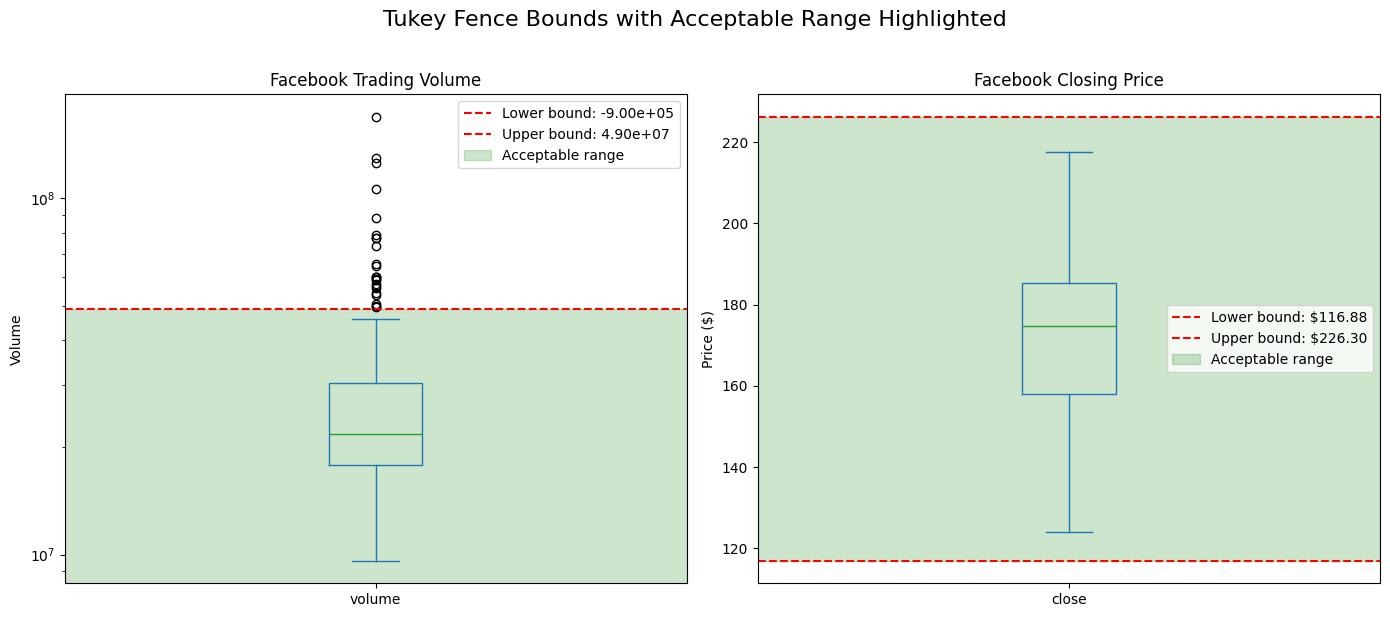

In [5]:
# Exercise 3: Fill area between Tukey fence bounds

# Create box plots with filled area between bounds
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Volume box plot with filled area
fb['volume'].plot(kind='box', ax=axes[0], title='Facebook Trading Volume')
axes[0].axhline(y=volume_lower, color='r', linestyle='--', label=f'Lower bound: {volume_lower:.2e}')
axes[0].axhline(y=volume_upper, color='r', linestyle='--', label=f'Upper bound: {volume_upper:.2e}')
# Fill between the bounds
axes[0].axhspan(ymin=volume_lower, ymax=volume_upper, alpha=0.2, color='green', label='Acceptable range')
axes[0].set_ylabel('Volume')
axes[0].set_yscale('log')
axes[0].legend()

# Close price box plot with filled area
fb['close'].plot(kind='box', ax=axes[1], title='Facebook Closing Price')
axes[1].axhline(y=close_lower, color='r', linestyle='--', label=f'Lower bound: ${close_lower:.2f}')
axes[1].axhline(y=close_upper, color='r', linestyle='--', label=f'Upper bound: ${close_upper:.2f}')
# Fill between the bounds
axes[1].axhspan(ymin=close_lower, ymax=close_upper, alpha=0.2, color='green', label='Acceptable range')
axes[1].set_ylabel('Price ($)')
axes[1].legend()

plt.suptitle('Tukey Fence Bounds with Acceptable Range Highlighted', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

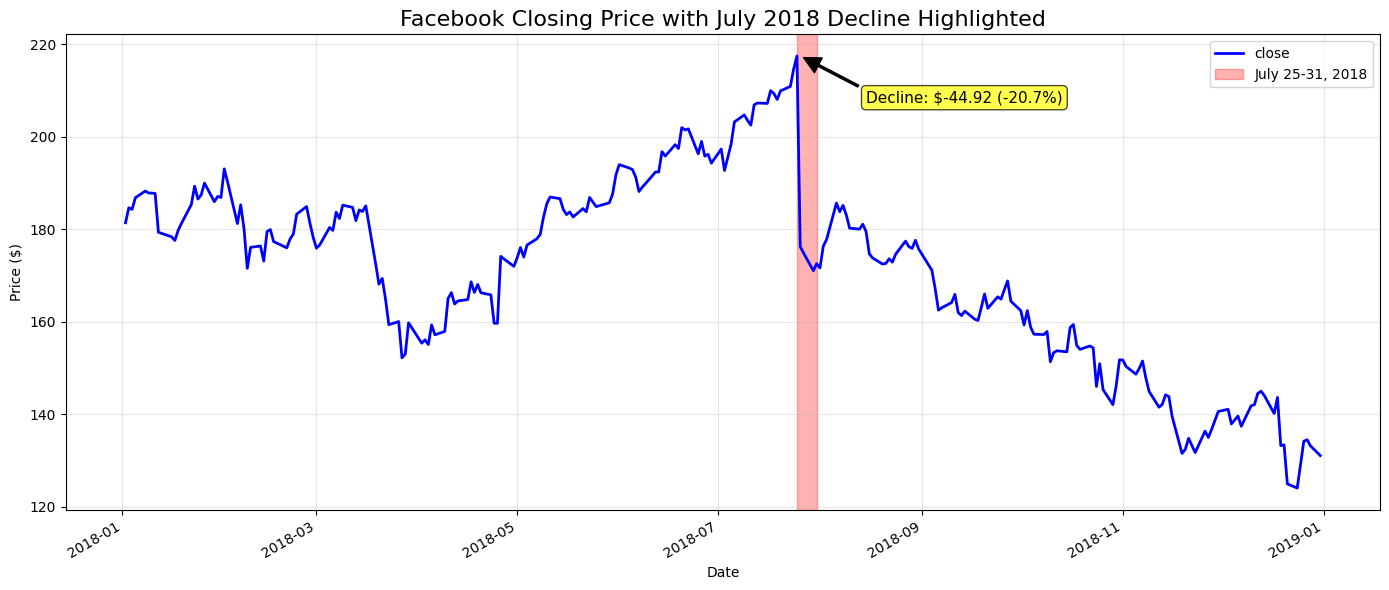

In [6]:
# Exercise 4: Shade a date range

# Convert string dates to datetime for axvspan
start_date = '2018-07-25'
end_date = '2018-07-31'

# Create line plot of closing price
fig, ax = plt.subplots(figsize=(14, 6))
fb['close'].plot(ax=ax, linewidth=2, color='blue')

# Shade the date range
ax.axvspan(start_date, end_date, alpha=0.3, color='red', label='July 25-31, 2018')

# Calculate price change during this period
price_before = fb.loc[:start_date, 'close'].iloc[-1] if start_date in fb.index else fb.loc[:start_date].iloc[-1]['close']
price_after = fb.loc[end_date:, 'close'].iloc[0] if end_date in fb.index else fb.loc[end_date:].iloc[0]['close']
price_change = price_after - price_before
percent_change = (price_change / price_before) * 100

# Add annotation for the decline
ax.annotate(f'Decline: ${price_change:.2f} ({percent_change:.1f}%)',
            xy=(pd.Timestamp('2018-07-26'), price_before),
            xytext=(pd.Timestamp('2018-08-15'), price_before - 10),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('Facebook Closing Price with July 2018 Decline Highlighted', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

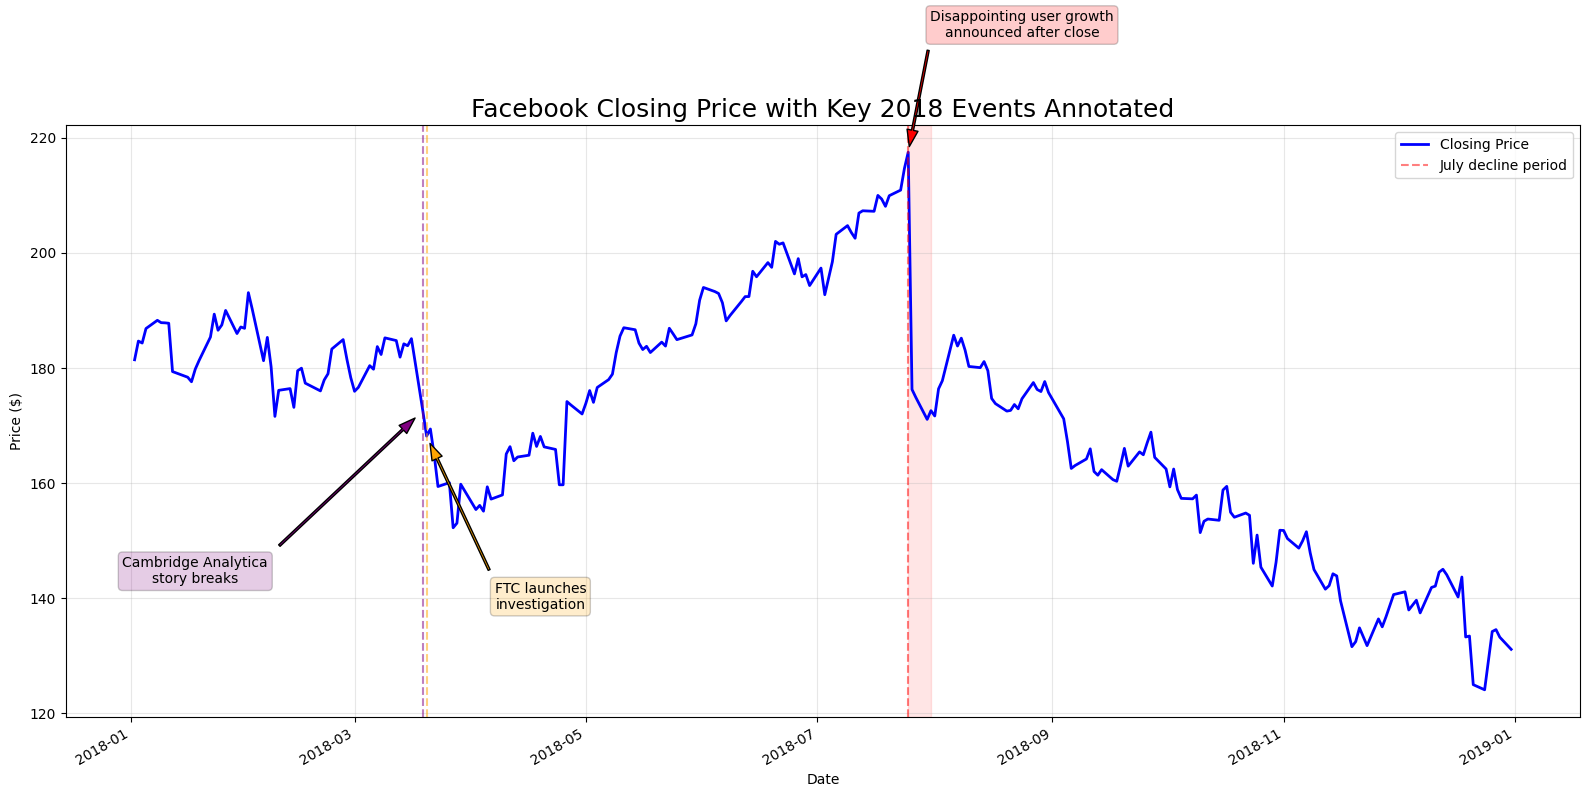

In [7]:
# Exercise 5: Annotate three events

# Create line plot of closing price
fig, ax = plt.subplots(figsize=(16, 8))
fb['close'].plot(ax=ax, linewidth=2, color='blue')

# Define events with dates, descriptions, and annotation positions
events = [
    {
        'date': '2018-07-25',
        'description': 'Disappointing user growth\nannounced after close',
        'xytext_offset': (30, 20),
        'color': 'red'
    },
    {
        'date': '2018-03-19',
        'description': 'Cambridge Analytica\nstory breaks',
        'xytext_offset': (-60, -30),
        'color': 'purple'
    },
    {
        'date': '2018-03-20',
        'description': 'FTC launches\ninvestigation',
        'xytext_offset': (30, -30),
        'color': 'orange'
    }
]

# Add annotations for each event
for event in events:
    event_date = pd.Timestamp(event['date'])
    
    # Get price at event date (or nearest date)
    if event_date in fb.index:
        event_price = fb.loc[event_date, 'close']
    else:
        # Find nearest date
        nearest_idx = fb.index.get_indexer([event_date], method='nearest')[0]
        event_price = fb.iloc[nearest_idx]['close']
        event_date = fb.index[nearest_idx]
    
    # Add vertical line for event
    ax.axvline(x=event_date, color=event['color'], linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Add annotation
    ax.annotate(
        event['description'],
        xy=(event_date, event_price),
        xytext=(event_date + pd.Timedelta(days=event['xytext_offset'][0]), 
                event_price + event['xytext_offset'][1]),
        arrowprops=dict(facecolor=event['color'], shrink=0.05, width=1.5, headwidth=8),
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=event['color'], alpha=0.2),
        horizontalalignment='center'
    )

# Also shade the July decline period
ax.axvspan('2018-07-25', '2018-07-31', alpha=0.1, color='red', label='July decline period')

ax.set_title('Facebook Closing Price with Key 2018 Events Annotated', fontsize=18)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.grid(True, alpha=0.3)
ax.legend(['Closing Price', 'July decline period'])

plt.tight_layout()
plt.show()

Using 'tab10' colormap (default qualitative):


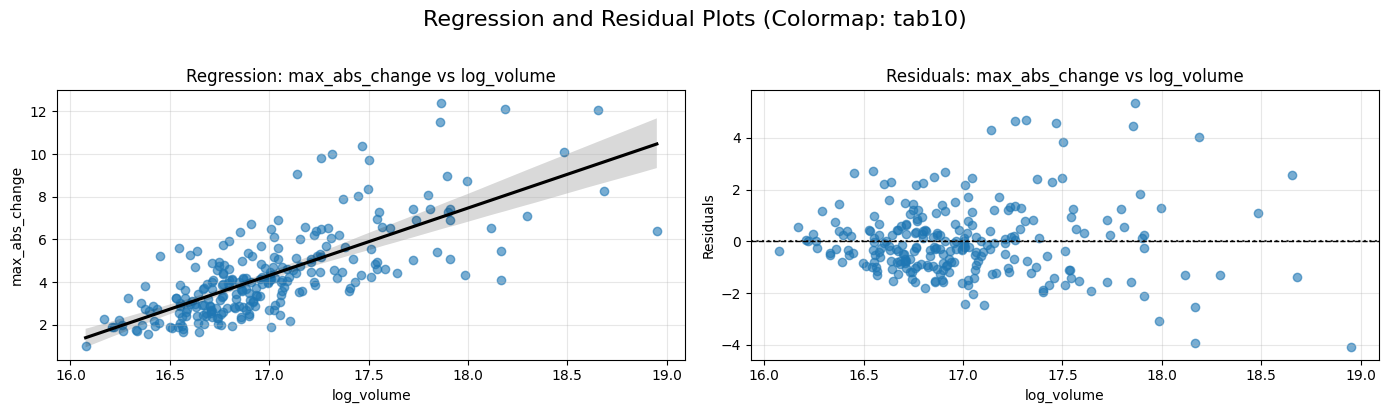


Using 'Set1' colormap (another qualitative option):


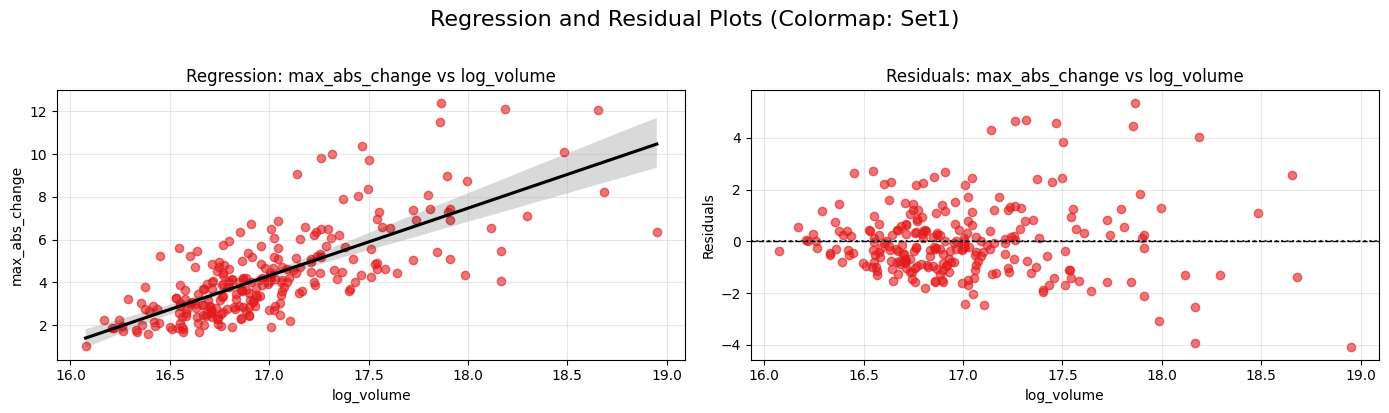


Using 'viridis' colormap (sequential - just for demonstration):


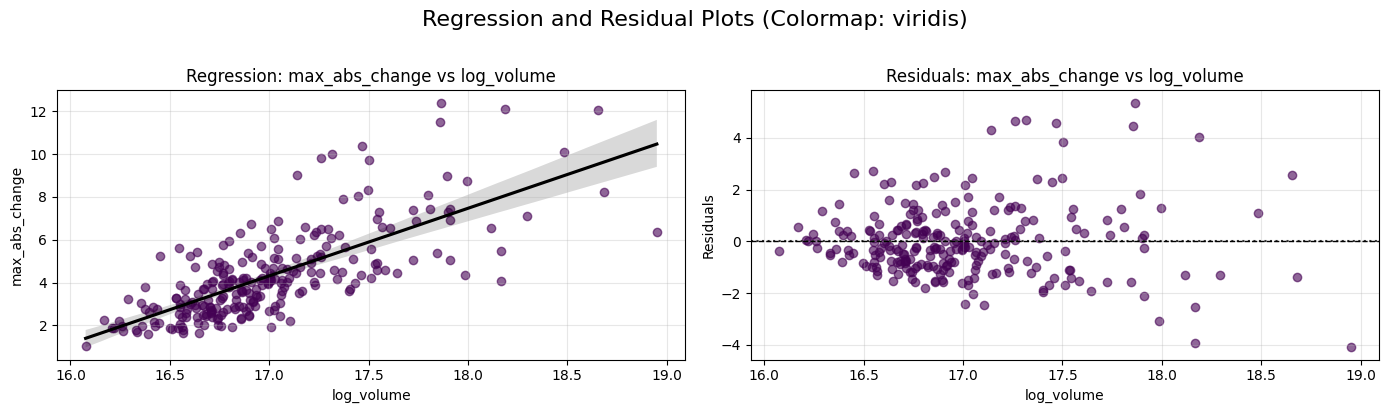

(<Figure size 1400x400 with 2 Axes>,
 array([[<Axes: title={'center': 'Regression: max_abs_change vs log_volume'}, xlabel='log_volume', ylabel='max_abs_change'>,
         <Axes: title={'center': 'Residuals: max_abs_change vs log_volume'}, xlabel='log_volume', ylabel='Residuals'>]],
       dtype=object))

In [10]:
# Exercise 6: Modify reg_resid_plots() with colormap

def reg_resid_plots_cmap(data, colormap='tab10'):
    
    # Get all combinations of columns (pairs)
    num_cols = data.shape[1]
    col_pairs = list(itertools.combinations(data.columns, 2))
    
    # Calculate number of rows needed for subplots (2 plots per pair)
    n_rows = len(col_pairs)
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    
    # Handle case when there's only one row
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Get colormap
    cmap = plt.get_cmap(colormap)
    
    # Create regression and residual plots for each pair
    for i, (x_col, y_col) in enumerate(col_pairs):
        color = cmap(i / max(len(col_pairs), 1))  # Get color from colormap
        
        # Regression plot
        sns.regplot(x=x_col, y=y_col, data=data, ax=axes[i, 0], 
                    scatter_kws={'color': color, 'alpha': 0.6},
                    line_kws={'color': 'black'})
        axes[i, 0].set_title(f'Regression: {y_col} vs {x_col}', fontsize=12)
        axes[i, 0].set_xlabel(x_col)
        axes[i, 0].set_ylabel(y_col)
        axes[i, 0].grid(True, alpha=0.3)
        
        # Residual plot
        sns.residplot(x=x_col, y=y_col, data=data, ax=axes[i, 1],
                      scatter_kws={'color': color, 'alpha': 0.6})
        axes[i, 1].set_title(f'Residuals: {y_col} vs {x_col}', fontsize=12)
        axes[i, 1].set_xlabel(x_col)
        axes[i, 1].set_ylabel('Residuals')
        axes[i, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Regression and Residual Plots (Colormap: {colormap})', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig, axes

# Prepare data for regression
fb_reg_data = fb.assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
)[['log_volume', 'max_abs_change']].dropna()

# Test the function with different colormaps
print("Using 'tab10' colormap (default qualitative):")
reg_resid_plots_cmap(fb_reg_data, colormap='tab10')

print("\nUsing 'Set1' colormap (another qualitative option):")
reg_resid_plots_cmap(fb_reg_data, colormap='Set1')

print("\nUsing 'viridis' colormap (sequential - just for demonstration):")
reg_resid_plots_cmap(fb_reg_data, colormap='viridis')

## Summary/Conclusion

Throughout this supplementary activity, I applied the data visualization techniques I've learned to work with real-world Facebook stock and earthquake datasets. I found the heatmap exercise particularly interesting because it showed me how to isolate specific data subsets (earthquakes with mb magType) and visualize the correlation between magnitude and tsunami occurrence, which helped me understand how different factors relate to each other. The box plot exercises challenged me to implement Tukey fences using the quantile method, and I was proud when I successfully filled the area between bounds to create clear visual indicators of acceptable ranges this taught me how statistical concepts can be transformed into meaningful visual elements. The annotation exercises were my favorite because they made the stock price data come alive by connecting it to real events like the Cambridge Analytica scandal and FTC investigation, showing me how context transforms raw data into a compelling story. Finally, customizing the reg_resid_plots function with different matplotlib colormaps helped me understand how color choices can dramatically improve the readability of visualizations. This activity solidified my understanding that effective data visualization is not just about plotting data, but about thoughtfully designing each element to communicate insights clearly and tell a coherent story with the data.

# END